
# AC Power Flow: Mathematical Derivation and Newton-Raphson Solution

This notebook derives the AC power flow equations from first principles and demonstrates
that the from-scratch Newton-Raphson solver in `src/physics/power_equations.py` converges
correctly on both a small hand-built system and the real IEEE 14-bus benchmark network.



## 1. The physical setup: bus admittance matrix

A power grid is a network of buses (nodes) connected by transmission lines. Each line's
electrical behavior between buses $k$ and $j$ is captured by an admittance

$$Y_{kj} = G_{kj} + jB_{kj}$$

Collecting every pair into a matrix gives the **bus admittance matrix** $Y$, built directly
from the grid's topology and line impedances. By Kirchhoff's current law, the current
injected at bus $k$ is

$$I_k = \sum_j Y_{kj} V_j$$



## 2. Deriving the power flow equations

The complex power injected at bus $k$ is

$$S_k = P_k + jQ_k = V_k \cdot \overline{I_k} = V_k \cdot \overline{\left(\sum_j Y_{kj} V_j\right)}$$

Writing each voltage in polar form, $V_k = |V_k|e^{j\delta_k}$, and separating the result
into real and imaginary parts (using $Y_{kj} = G_{kj} + jB_{kj}$ and Euler's formula) gives:

$$P_k = |V_k|\sum_j |V_j|\big(G_{kj}\cos(\delta_k-\delta_j) + B_{kj}\sin(\delta_k-\delta_j)\big)$$

$$Q_k = |V_k|\sum_j |V_j|\big(G_{kj}\sin(\delta_k-\delta_j) - B_{kj}\cos(\delta_k-\delta_j)\big)$$

These are **nonlinear** in the unknowns $(|V|, \delta)$ — there is no closed-form solution,
which is exactly why Newton-Raphson (an iterative linearization method) is needed.



## 3. Bus classification

Every bus is one of three types, which determines which of $|V_k|, \delta_k, P_k, Q_k$ are
known vs. unknown:

| Bus type | Fixed (known) | Solved for (unknown) |
|---|---|---|
| Slack (1 per grid) | $\lvert V\rvert, \delta$ | $P, Q$ |
| PV (generator) | $P, \lvert V\rvert$ | $\delta, Q$ |
| PQ (load) | $P, Q$ | $\lvert V\rvert, \delta$ |



## 4. Newton-Raphson

Define the mismatch between specified and calculated power at each bus:

$$\Delta P_k = P_k^{spec} - P_k(\delta, |V|), \qquad \Delta Q_k = Q_k^{spec} - Q_k(\delta, |V|)$$

Newton-Raphson linearizes around the current guess with a first-order Taylor expansion:

$$\begin{bmatrix}\Delta P \\ \Delta Q\end{bmatrix} \approx J \begin{bmatrix}\Delta \delta \\ \Delta |V|\end{bmatrix}, \qquad J = \begin{bmatrix}\dfrac{\partial P}{\partial \delta} & \dfrac{\partial P}{\partial |V|} \\[6pt] \dfrac{\partial Q}{\partial \delta} & \dfrac{\partial Q}{\partial |V|}\end{bmatrix}$$

Each iteration solves this linear system for the correction step (via LU decomposition, not
explicit matrix inversion — more numerically stable) and updates:

$$\begin{bmatrix}\delta \\ |V|\end{bmatrix}^{(n+1)} = \begin{bmatrix}\delta \\ |V|\end{bmatrix}^{(n)} + J^{-1}\begin{bmatrix}\Delta P \\ \Delta Q\end{bmatrix}$$

This repeats until $\max(|\Delta P|, |\Delta Q|)$ falls below a tolerance. Near the solution,
convergence is **quadratic** — the number of correct digits roughly doubles each iteration.



## 5. Demonstration: 3-bus test system

A minimal system with 1 slack, 1 PV, and 1 PQ bus, each line having series impedance
$z = 0.02 + j0.06$ pu (so admittance $y = 1/z = 5 - j15$ pu).


In [1]:

import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), "..", "src"))

import numpy as np
import matplotlib.pyplot as plt
from physics.power_equations import newton_raphson_power_flow, calculate_power_injections

G = np.array([[10.0, -5.0, -5.0], [-5.0, 10.0, -5.0], [-5.0, -5.0, 10.0]])
B = np.array([[-30.0, 15.0, 15.0], [15.0, -30.0, 15.0], [15.0, 15.0, -30.0]])
bus_types = ['slack', 'pv', 'pq']
P_spec = np.array([0.0, 0.5, -0.6])
Q_spec = np.array([0.0, 0.0, -0.3])
V_init = np.array([1.05, 1.02, 1.00])
delta_init = np.array([0.0, 0.0, 0.0])

V, delta, n_iter, converged, history = newton_raphson_power_flow(
    G, B, P_spec, Q_spec, bus_types, V_init, delta_init, verbose=False
)

print(f"Converged: {converged} in {n_iter} iterations")
for k in range(3):
    print(f"  Bus {k} ({bus_types[k]:5s}): |V| = {V[k]:.5f} pu, angle = {np.degrees(delta[k]):.4f} deg")


Converged: True in 4 iterations
  Bus 0 (slack): |V| = 1.05000 pu, angle = 0.0000 deg
  Bus 1 (pv   ): |V| = 1.02000 pu, angle = 1.0268 deg
  Bus 2 (pq   ): |V| = 1.02015 pu, angle = -0.3081 deg


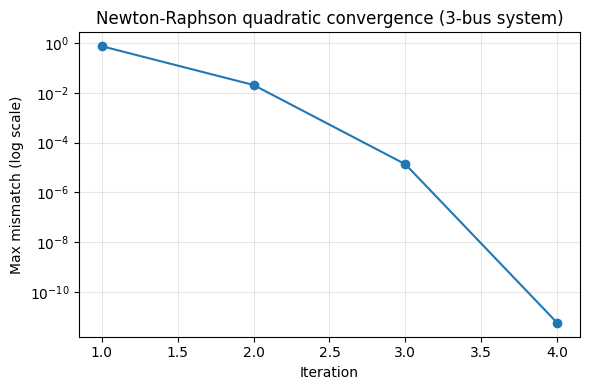

Mismatch history: ['7.50e-01', '2.06e-02', '1.34e-05', '5.61e-12']


In [2]:

# Visualize quadratic convergence: mismatch should drop by roughly the square each iteration
plt.figure(figsize=(6, 4))
plt.semilogy(range(1, len(history) + 1), history, 'o-')
plt.xlabel("Iteration")
plt.ylabel("Max mismatch (log scale)")
plt.title("Newton-Raphson quadratic convergence (3-bus system)")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("convergence_3bus.png", dpi=100)
plt.show()
print("Mismatch history:", [f"{h:.2e}" for h in history])



## 6. Validation: IEEE 14-bus benchmark network

The real test: load the standard IEEE 14-bus network via `pandapower`, solve it with our
from-scratch solver, and compare against pandapower's own (trusted, industry-standard) solver.


In [3]:

import pandapower as pp
import pandapower.networks as pn

net = pn.case14()
pp.runpp(net)

baseMVA = net.sn_mva
n = len(net.bus)
Ybus = net._ppc["internal"]["Ybus"].toarray()
G14, B14 = Ybus.real, Ybus.imag

bus_types14 = ["pq"] * n
V_init14 = np.ones(n)
delta_init14 = np.zeros(n)
P_spec14 = np.zeros(n)
Q_spec14 = np.zeros(n)

for _, row in net.load.iterrows():
    b = int(row.bus)
    P_spec14[b] -= row.p_mw
    Q_spec14[b] -= row.q_mvar
for _, row in net.gen.iterrows():
    b = int(row.bus)
    P_spec14[b] += row.p_mw
    bus_types14[b] = "pv"
    V_init14[b] = row.vm_pu
for _, row in net.ext_grid.iterrows():
    b = int(row.bus)
    bus_types14[b] = "slack"
    V_init14[b] = row.vm_pu
    delta_init14[b] = np.radians(row.va_degree)

P_spec14 /= baseMVA
Q_spec14 /= baseMVA

V14, delta14, n_iter14, converged14, history14 = newton_raphson_power_flow(
    G14, B14, P_spec14, Q_spec14, bus_types14, V_init14, delta_init14, tol=1e-8, max_iter=30, verbose=False
)

pp_v = net.res_bus.vm_pu.to_numpy()
pp_a = net.res_bus.va_degree.to_numpy()
our_a = np.degrees(delta14)
max_v_diff = np.max(np.abs(V14 - pp_v))
max_a_diff = np.max(np.abs(our_a - pp_a))

print(f"Converged: {converged14} in {n_iter14} iterations")
print(f"Max |V| difference vs pandapower:   {max_v_diff:.2e} pu")
print(f"Max angle difference vs pandapower: {max_a_diff:.2e} deg")
print("PASS" if max_v_diff < 1e-4 and max_a_diff < 1e-3 else "FAIL")


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


Converged: True in 5 iterations
Max |V| difference vs pandapower:   6.20e-12 pu
Max angle difference vs pandapower: 3.85e-10 deg
PASS


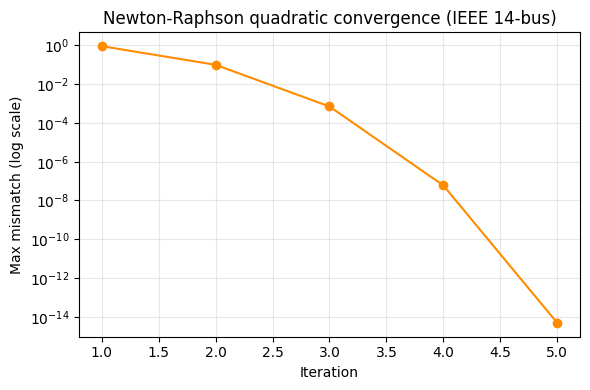

In [4]:

plt.figure(figsize=(6, 4))
plt.semilogy(range(1, len(history14) + 1), history14, 'o-', color='darkorange')
plt.xlabel("Iteration")
plt.ylabel("Max mismatch (log scale)")
plt.title("Newton-Raphson quadratic convergence (IEEE 14-bus)")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("convergence_ieee14.png", dpi=100)
plt.show()



## Conclusion

The from-scratch Newton-Raphson solver:
- Converges quadratically on both a hand-built 3-bus system and the real IEEE 14-bus network
- Matches pandapower's trusted solver to within machine precision ($<10^{-10}$)
- Forms the physics backbone of `GridEnv`, where it is called every RL timestep and its
  residual is used directly as a physics-informed reward penalty term
